In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.family'] = 'Malgun Gothic'

In [77]:
df = pd.read_excel('file1/students.xlsx', index_col='번호')
df['합계'] = df['국어']+df['영어']+df['수학'].astype(int)
df['평균'] = df['합계']/3
df['등수'] = df['합계'].rank(ascending=False, method='min').astype(int)
df

,이름,학교,학년,키,국어,영어,수학,SW특기,합계,평균,등수
번호,,,,,,,,,,,
1,Eadmund,신림고,2,171,56,92,60,c,208,69.333333,30
2,Kirbee,구로고,1,199,53,10,45,C,108,36.000000,99
3,Appolonia,구로고,3,193,77,52,81,C,210,70.000000,28
4,Avery,구로고,2,187,59,35,43,C,137,45.666667,90
5,Dallis,디지털고,1,209,97,57,76,C,230,76.666667,13
...,...,...,...,...,...,...,...,...,...,...,...
96,Luke,신림고,3,187,91,63,59,Python,213,71.000000,26
97,Nada,구로고,3,170,60,89,55,PYTHON,204,68.000000,36
98,Fiona,신림고,1,200,97,95,84,C,276,92.000000,2


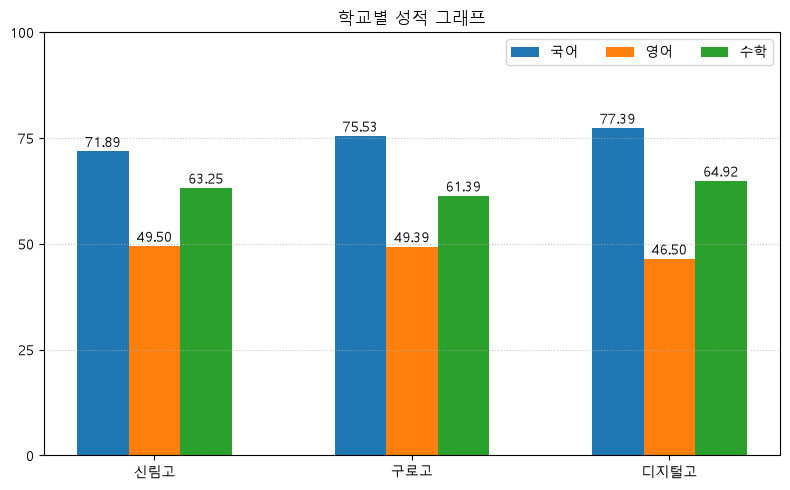

In [ ]:
x = np.array(df['학교'].unique())
idx = np.arange(len(x))
y1 = np.array(df.groupby('학교')['국어'].mean())
y2 = np.array(df.groupby('학교')['영어'].mean())
y3 = np.array(df.groupby('학교')['수학'].mean())

plt.figure(figsize=(8,5))
plt.title('학교별 성적 그래프')
plt.bar(idx-0.2,y1, label='국어', width=0.2)
plt.bar(idx,y2, label='영어', width=0.2)
plt.bar(idx+0.2,y3, label='수학', width=0.2)

plt.yticks([0,25,50,75,100])
plt.xticks(idx, x)
plt.grid(axis='y', linestyle=':', alpha=0.7)


for i, (v1, v2, v3) in enumerate(zip(y1, y2, y3)):
    plt.text(i, y2[i]+1, f'{v2:.2f}', ha='center')
    plt.text(i-0.2, y1[i]+1, f'{v1:.2f}', ha='center')
    plt.text(i+0.2, y3[i]+1, f'{v3:.2f}', ha='center')

plt.legend(ncol = 3)
plt.tight_layout()
plt.show()

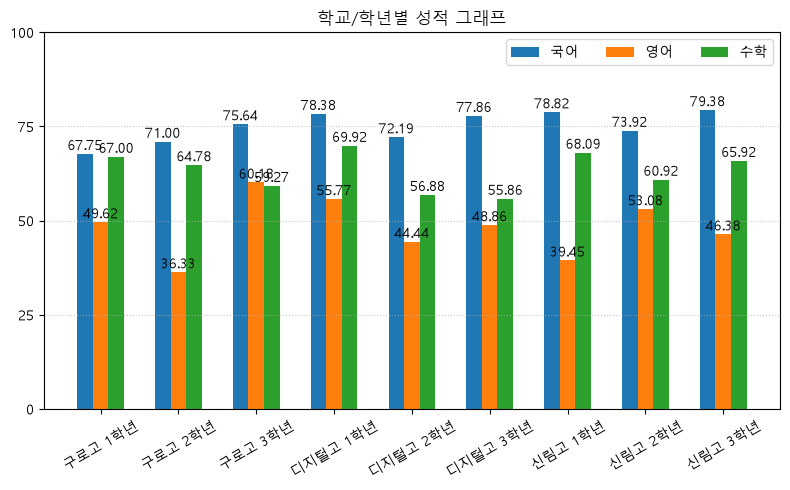

In [114]:
# x = np.array(df['학교'].unique())
# df.groupby(['학교','학년'])['국어'].mean()
# x = [0,1,2,3,4,5,6,7,8]
# idx = np.arange(len(x))
# y1 = np.array(df.groupby(['학교','학년'])['국어'].mean())
# y2 = np.array(df.groupby(['학교','학년'])['영어'].mean())
# y3 = np.array(df.groupby(['학교','학년'])['수학'].mean())

grouped = df.groupby(['학교', '학년'])
labels = [f"{sch} {grd}학년" for sch, grd in grouped.groups.keys()]

# x축 위치 설정 (그룹 개수에 맞게 동적으로 계산)
x = np.arange(len(grouped))
idx = x

y1 = np.array(grouped['국어'].mean())
y2 = np.array(grouped['영어'].mean())
y3 = np.array(grouped['수학'].mean())

plt.figure(figsize=(8,5))
plt.title('학교/학년별 성적 그래프')
plt.bar(idx-0.2,y1, label='국어', width=0.2)
plt.bar(idx,y2, label='영어', width=0.2)
plt.bar(idx+0.2,y3, label='수학', width=0.2)

for i, (v1, v2, v3) in enumerate(zip(y1, y2, y3)):
    plt.text(i, y2[i]+1, f'{v2:.2f}', ha='center')
    plt.text(i-0.2, y1[i]+1, f'{v1:.2f}', ha='center')
    plt.text(i+0.2, y3[i]+1, f'{v3:.2f}', ha='center')

plt.yticks([0,25,50,75,100])
plt.xticks(idx, labels, rotation=30)
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.legend(ncol=3)
plt.tight_layout()
plt.show()